In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import ultralytics
print(f"✅ Ultralytics version installed: {ultralytics.__version__}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics version installed: 8.4.14


In [ ]:

from ultralytics import YOLO
import os

# Load pretrained YOLOv11n model
model = YOLO("yolo11n.pt")
print("🎯 Pretrained YOLOv11n model loaded successfully!")


base_dir = "/content/drive/MyDrive/All-IDB dataset"


folders_to_use = [
    os.path.join(base_dir, "train", "Blast"),
    os.path.join(base_dir, "train", "nonblast"),
    os.path.join(base_dir, "val", "Blast"),
    os.path.join(base_dir, "val", "nonblast"),
]


for folder in folders_to_use:
    if os.path.exists(folder):
        folder_name = folder.replace(base_dir, "").strip("/").replace("/", "_")
        print(f"🔍 Running inference on: {folder_name}")

        model.predict(
            source=folder,
            imgsz=640,
            conf=0.25,
            save=True,
            save_txt=True,
            project="runs/detect",
            name=f"unannotated_{folder_name}_results"
        )
    else:
        print(f"⚠️ Folder not found: {folder}")

print("✅ Zero-shot inference completed for Blast and Nonblast folders!")
print("📁 Check results under 'runs/detect/unannotated_*_results'")


🎯 Pretrained YOLOv11n model loaded successfully!
🔍 Running inference on: train_Blast

image 1/100 /content/drive/MyDrive/All-IDB dataset/train/Blast/Im031_1.jpg: 640x640 2 apples, 11.0ms
image 2/100 /content/drive/MyDrive/All-IDB dataset/train/Blast/Im032_1.jpg: 640x640 (no detections), 16.5ms
image 3/100 /content/drive/MyDrive/All-IDB dataset/train/Blast/Im033_1.jpg: 640x640 3 apples, 9.0ms
image 4/100 /content/drive/MyDrive/All-IDB dataset/train/Blast/Im034_1.jpg: 640x640 (no detections), 8.3ms
image 5/100 /content/drive/MyDrive/All-IDB dataset/train/Blast/Im035_1.jpg: 640x640 2 apples, 8.1ms
image 6/100 /content/drive/MyDrive/All-IDB dataset/train/Blast/Im036_1.jpg: 640x640 6 apples, 8.1ms
image 7/100 /content/drive/MyDrive/All-IDB dataset/train/Blast/Im037_1.jpg: 640x640 3 apples, 1 donut, 8.4ms
image 8/100 /content/drive/MyDrive/All-IDB dataset/train/Blast/Im038_1.jpg: 640x640 1 apple, 1 donut, 8.2ms
image 9/100 /content/drive/MyDrive/All-IDB dataset/train/Blast/Im039_1.jpg: 640x6

✅ 100 detected images found.

ℱ Detection Result 1


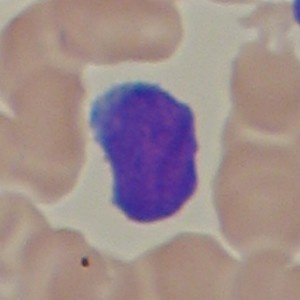


ℱ Detection Result 2


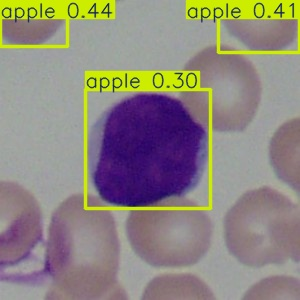


ℱ Detection Result 3


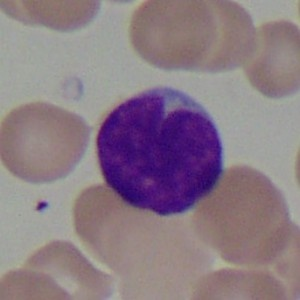


ℱ Detection Result 4


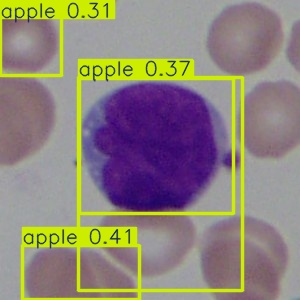


ℱ Detection Result 5


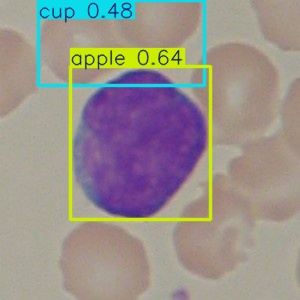

In [ ]:
import os
from IPython.display import Image, display

result_path = "/content/runs/detect/runs/detect/unannotated_train_Blast_results"
display_count = 5

if os.path.exists(result_path):
    detected_images = [os.path.join(result_path, f) for f in os.listdir(result_path) if f.endswith((".jpg", ".png"))]
    print(f"✅ {len(detected_images)} detected images found.")

    for i, img_path in enumerate(detected_images[:display_count]):
        print(f"\nℱ Detection Result {i+1}")
        display(Image(filename=img_path))
else:
    print("❌ No results found. Check if inference ran correctly.")

In [ ]:

import zipfile
import os

zip_path = "/content/drive/MyDrive/Leukemia.v4i.yolov11.zip"
extract_path = "/content/Leukemia_dataset"

# Unzip dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for f in files[:3]:
        print(f"{subindent}{f}")


Leukemia_dataset/
  README.dataset.txt
  data.yaml
  README.roboflow.txt
  valid/
    labels/
      Im076_1_jpg.rf.df9b317a34f909761307f1d1e860dd5b.txt
      Im196_0_jpg.rf.cd2c91ec7dcfe54a20ee0eb80fdcb78a.txt
      Im179_0_jpg.rf.c0ed6aaacbfb22f61ed9cf9d3f3d4015.txt
    images/
      Im186_0_jpg.rf.797565ad73b66e33e8f48a5d96525ef2.jpg
      Im196_0_jpg.rf.cd2c91ec7dcfe54a20ee0eb80fdcb78a.jpg
      Im227_0_jpg.rf.cbc386ef21d4a496b83c221e43749bae.jpg
  train/
    labels/
      Im212_0_jpg.rf.2e50cf92fea06c035217fc4b39932eb7.txt
      Im124_1_jpg.rf.8339875c095b1b7de1dc04336b387e99.txt
      Im211_0_jpg.rf.dd729d16b6ad9d620e1d74829dd4dbab.txt
    images/
      Im187_0_jpg.rf.8b857154f5292edfd032538c59f6cb01.jpg
      Im202_0_jpg.rf.3e35d916ca88921e9a69be5a3f4837b3.jpg
      Im102_1_jpg.rf.a2adb929fc9ff2105d12a1dbc61d979e.jpg


In [ ]:

from ultralytics import YOLO
import yaml
import os

# Load pretrained YOLOv11 model
model = YOLO("yolo11n.pt")


data_yaml_path = "/content/Leukemia_dataset/data.yaml"


with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)


data_config['path'] = "/content/Leukemia_dataset"
print(f"✅ data.yaml updated: 'path' set to '{data_config['path']}'.")


val_key = 'val' if 'val' in data_config else ('valid' if 'valid' in data_config else None)

if val_key and data_config.get('train'):

    expected_val_images_path = os.path.join(data_config['path'], data_config[val_key], 'images')
    if not os.path.exists(expected_val_images_path) or not os.listdir(expected_val_images_path):
        print(f"⚠️ Warning: Validation path '{data_config[val_key]}' (expected at '{expected_val_images_path}') in data.yaml is missing or empty. Setting 'val' to use 'train' images.")
        data_config[val_key] = data_config['train']
        print(f"✅ data.yaml updated: '{val_key}' now points to '{data_config['train']}'.")
elif val_key:
    print(f"❌ Error: '{val_key}' path found in data.yaml but 'train' path is missing. Cannot set fallback validation path.")
else:
    print("ℹ️ No 'val' or 'valid' path found in data.yaml. Proceeding without explicit validation path configuration.")


with open(data_yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(f"📝 data.yaml content after potential modification:\n{yaml.dump(data_config, default_flow_style=False)}")


# Train the model
results = model.train(
    data=data_yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    name="leukemia_yolov11",
    project="runs/train",
    lr0=0.001,
    patience=20
)

print("✅ Training complete! Best weights saved under runs/train/leukemia_yolov11/weights/best.pt")

✅ data.yaml updated: 'path' set to '/content/Leukemia_dataset'.
⚠️ Warning: Validation path '../valid/images' (expected at '/content/Leukemia_dataset/../valid/images/images') in data.yaml is missing or empty. Setting 'val' to use 'train' images.
✅ data.yaml updated: 'val' now points to '../train/images'.
📝 data.yaml content after potential modification:
names:
- blast
- nonblast
nc: 2
path: /content/Leukemia_dataset
roboflow:
  license: CC BY 4.0
  project: leukemia-tlk05
  url: https://universe.roboflow.com/gowris-workspace/leukemia-tlk05/dataset/4
  version: 4
  workspace: gowris-workspace
test: ../test/images
train: ../train/images
val: ../train/images

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, 

In [ ]:

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

# Load model
trained_model_path = "/content/runs/detect/runs/train/leukemia_yolov112/weights/best.pt"
model = YOLO(trained_model_path)

print("🎯 Trained model loaded successfully!")


test_image_path = "/content/drive/MyDrive/All-IDB dataset/val/Blast/Im006_1.jpg"


if not os.path.exists(test_image_path):
    print(f"❌ Test image not found: {test_image_path}")
    print("Please update the test_image_path variable with your actual image path")
else:
    print(f"🔍 Testing on: {test_image_path}")

    # Run inference
    results = model.predict(
        source=test_image_path,
        imgsz=640,
        conf=0.25,
        save=True,
        save_txt=True,
        project="runs/detect",
        name="trained_model_test"
    )


    for i, r in enumerate(results):
        print(f"\n📊 Detection Result {i+1}")


        im_array = r.plot()
        im_array_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)


        plt.figure(figsize=(12, 8))
        plt.imshow(im_array_rgb)
        plt.axis('off')
        plt.title(f"Trained Model Detection - {os.path.basename(test_image_path)}")
        plt.show()


        print("📋 Detection Details:")
        if len(r.boxes) > 0:
            for j, box in enumerate(r.boxes):
                class_id = int(box.cls[0])
                class_name = r.names[class_id]
                confidence = float(box.conf[0])
                bbox_coords = box.xyxy[0].tolist()

                print(f"   Object {j+1}: {class_name}")
                print(f"   Confidence: {confidence:.3f}")
                print(f"   BBox: {[round(coord, 2) for coord in bbox_coords]}")
                print("   ---")
        else:
            print("   No objects detected")

        print(f"💾 Results saved to: {r.save_dir}")

print("✅ Testing completed!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/runs/train/leukemia_yolov112/weights/best.pt'